# **Multilabel Classification Test (with smoke set)**

# **Imports**

In [ ]:

from earthscape.utils.constants import ES_VERSION_SPLIT_DIR, SMOKE_VERSION_SPLIT_DIR, MODEL_CLF_DIR, SG_MAPPING
from earthscape.utils import set_seed
from earthscape.loaders import ESDataset_Classification, get_norm_stats
from earthscape.models import create_resnet_clf, create_vit_clf
from earthscape.train import BCEFocalLogits, train_model, plot_training_curves, train_metadata
from earthscape.evaluation import get_optimal_thresholds, test_model, get_global_metrics, get_class_metrics, plot_pr_roc_curves

import os
import glob
import datetime
import pandas as pd
import geopandas as gpd
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# **Setup**

In [2]:
############################################################
# Define parameters for training, validation, and testing
############################################################

# set seed for reproducibility
seed = 111
set_seed(seed)


# define input features -> dict of informal name & list of channel file suffixes
# NOTE: input features are stacked in order of listed channels
# NOTE: baseline models accept one key:value pair; SGMap-Net accepts multiple k:v pairs
modality_configs = {
    # 'dem': {
    #     'channels': ['dem.tif']
    #     }
    # 'aerial': {
    #     'channels': ['aerialr.tif', 'aerialg.tif', 'aerialb.tif']
    #     },
    # 'osm': {
    #     'channels': ['osm.tif']
    #     }
    'multi': {
        'channels': ['dem.tif', 'aerialr.tif', 'aerialg.tif', 'osm.tif']
        }, 
    }


# get normalization parameters for input modalities/channels
norm_stats_path = f"{ES_VERSION_SPLIT_DIR}/train_stats.csv"
modality_configs = get_norm_stats(norm_stats_path, modality_configs)


# list of directories containing patch data
patch_dirs = [
    # f"{DATASET_DIR}/warren/patches", 
    # f"{DATASET_DIR}/howevalley/patches", 
    # f"{DATASET_DIR}/sonora/patches", 
    f"{SMOKE_VERSION_SPLIT_DIR}/patches"
    ]


# get patch IDs & create pytorch datasets...
# training set
train_patch_path = f"{SMOKE_VERSION_SPLIT_DIR}/smoke_train_id.geojson"
train = gpd.read_file(train_patch_path)
train_patch_ids = train['patch_id'].to_list()
train_dataset = ESDataset_Classification(train_patch_ids, patch_dirs, modality_configs, normalize=True, augment=True)

# validation set
val_patch_path = f"{SMOKE_VERSION_SPLIT_DIR}/smoke_val_id.geojson"
val = gpd.read_file(val_patch_path)
val_patch_ids = val['patch_id'].to_list()
val_dataset = ESDataset_Classification(val_patch_ids, patch_dirs, modality_configs, normalize=True, augment=False)

# test set
test_patch_path = f"{SMOKE_VERSION_SPLIT_DIR}/smoke_test_id.geojson"
test = gpd.read_file(test_patch_path)
test_patch_ids = test['patch_id'].to_list()
test_dataset = ESDataset_Classification(test_patch_ids, patch_dirs, modality_configs, normalize=True, augment=False)

# cross-domain test set
cross_patch_path = f"{SMOKE_VERSION_SPLIT_DIR}/smoke_test_cd.geojson"
cross = gpd.read_file(cross_patch_path)
cross_patch_ids = cross['patch_id'].to_list()
cross_dataset = ESDataset_Classification(cross_patch_ids, patch_dirs, modality_configs, normalize=True, augment=False)


# model hyperparameters & settings...
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 2
num_epochs = 5
in_channels = 4
encoder = 'vit'

if encoder is 'resnet18':
    model = create_resnet_clf(architecture=encoder, in_channels=in_channels, out_features=7).to(device)
elif encoder is 'vit':
    model = create_vit_clf(in_channels=in_channels, num_classes=7, image_size=256)
# encoder = 'resnext'
# model = SGMapNet_Classification(modality_configs, encoder, enable_attention=False, embedding_dim=512, num_heads=8, p_attn=0.0, p_resid=0.0).to(device)
optimizer = optim.Adam(model.parameters())


# dataloaders...
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
cross_loader = DataLoader(cross_dataset, batch_size=batch_size, shuffle=False, drop_last=True)


# input feature shape...
input_size = next(iter(train_loader))
input_size = {k: v for k, v in input_size.items() if k != "label"}
input_size = list(next(iter(input_size.values()))[:1].shape)


# loss...
gamma = 0.0
alpha = None
pos_weight = None
reduction = 'mean'

# alpha = torch.tensor(alpha, dtype=torch.float32).view(1, -1).to(device)
criterion = BCEFocalLogits(gamma=gamma, alpha=alpha, reduction=reduction).to(device)


# create output directory...
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
modality_str = '_'.join(list(modality_configs.keys()))
model_name = f"{encoder}_{modality_str}_{timestamp}"
output_dir = f"{MODEL_CLF_DIR}/{model_name}"
if not os.path.isdir(output_dir):
    os.makedirs(output_dir)


# log metadata
train_metadata(model_name, output_dir, seed,
             train_patch_path, train_patch_ids, val_patch_path, val_patch_ids, test_patch_path, test_patch_ids, cross_patch_path, cross_patch_ids,
             modality_configs, 
             batch_size, num_epochs, optimizer, criterion, model, input_size)

# **DataLoader Test**

In [3]:
###################################
# Example DataLoader Information
###################################

# extract example
example = next(iter(val_loader))

# print data report
for modality in example.keys():
    print(modality)
    print(f"{type(example[modality])}  |  {example[modality].dtype}  |  {example[modality].shape}  |  {example[modality].min()}  |  {example[modality].max()}")

label
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 7])  |  0.0  |  1.0
multi
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 4, 256, 256])  |  -2.453869104385376  |  5.250452995300293


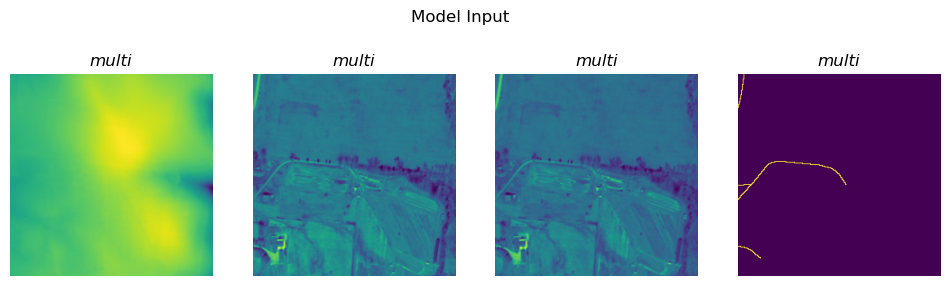

In [4]:
###################################
# Example DataLoader Visualization
###################################

# extract total number of channels to plot...
num_channels = 0
for k,v in example.items():
    if not 'label' in k:
        num_channels += v.shape[1]

# define number of columns & rows...
ncols = min(4, num_channels)
nrows = (num_channels // ncols) + 1

# setup figure...
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))
ax = ax.ravel()

# plot channels separately...
idx = 0
for k,v in example.items():
    if 'label' in k:
        label = v.detach().numpy()[0]
        fig.suptitle(f"Model Input")
    else:
        v_sample = v.detach().numpy()[0]
        for c in range(v_sample.shape[0]):
            img = v_sample[c]
            min_val = img.min()
            max_val = img.max()
            img = (img - min_val) / (max_val - min_val + 1e-8)
            ax[idx].imshow(img)
            ax[idx].set_axis_off()
            ax[idx].set_title(k, style='italic')
            idx += 1

# remove any extra subplot axes...
for j in range(idx, len(ax)):
    fig.delaxes(ax[j])

plt.show()

# **Training**

In [3]:
###############
# Train Model
###############

df_train = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, output_dir)

Epoch 1
TRAINING   -- Loss: 0.679  |  Accuracy: 52.38%  |  Time: 0.03 mins.
VALIDATION -- Loss: 0.663  |  Accuracy: 57.14%  |  Time: 0.01 mins.
New best model saved!


Epoch 2
TRAINING   -- Loss: 0.551  |  Accuracy: 76.19%  |  Time: 0.03 mins.
VALIDATION -- Loss: 0.532  |  Accuracy: 76.19%  |  Time: 0.01 mins.
New best model saved!


Epoch 3
TRAINING   -- Loss: 0.414  |  Accuracy: 83.33%  |  Time: 0.03 mins.
VALIDATION -- Loss: 0.540  |  Accuracy: 73.81%  |  Time: 0.01 mins.


Epoch 4
TRAINING   -- Loss: 0.383  |  Accuracy: 83.33%  |  Time: 0.03 mins.
VALIDATION -- Loss: 0.588  |  Accuracy: 71.43%  |  Time: 0.01 mins.


Epoch 5
TRAINING   -- Loss: 0.433  |  Accuracy: 83.33%  |  Time: 0.03 mins.
VALIDATION -- Loss: 0.622  |  Accuracy: 71.43%  |  Time: 0.01 mins.




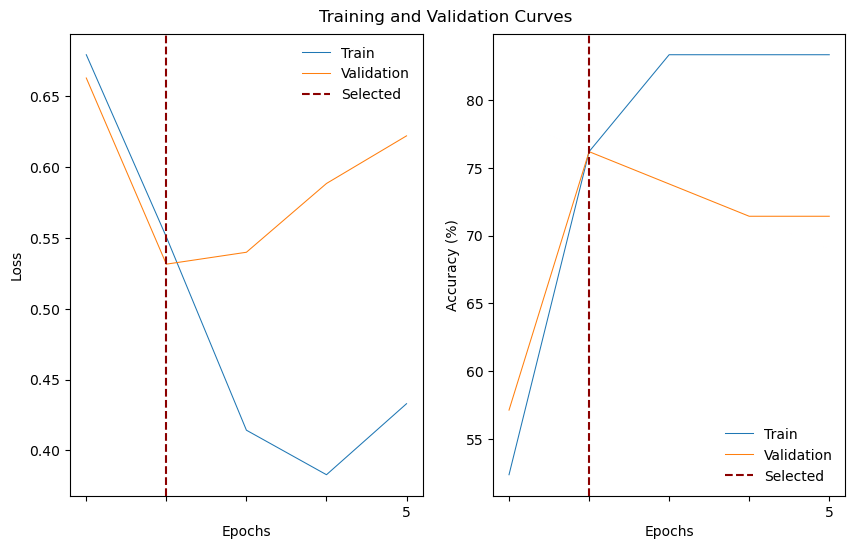

In [4]:
#########################
# Plot Training Curves
#########################

fig = plot_training_curves(df_train)

fig.savefig(f"{output_dir}/training_curves.png", dpi=300, bbox_inches='tight', pad_inches=0)

# **Inference**

## *Threshold Tuning*

In [5]:
#########################################################
# Tune Prediction Thresholds with F1 on Validation Set
#########################################################

# load model...
# model_path = glob.glob(f"{output_dir}/best_loss_epoch*.pth")[0]
# state_dict = torch.load(model_path, map_location=device, weights_only=False)
# model.load_state_dict(state_dict)

# optimize thresholds
optimal_thresholds = get_optimal_thresholds(model, val_loader, device)

## *In-domain Inference*

In [6]:
#############################################
# Inference & Global Performance Metrics
#############################################

# inference...
probabilities, targets = test_model(model, test_loader, device, baseline=True)

# global performance metrics
df_global = get_global_metrics(targets, probabilities, thresholds=optimal_thresholds)
df_global.to_csv(f"{output_dir}/id_global.csv", index=False)

df_global.head()

,Precision (Macro),Recall (Macro),F1 (Macro),AUC (Macro),mAP (Macro),Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro)
0,0.452381,0.619048,0.484972,0.402778,0.590317,0.690476,0.809524,0.725294,0.453333,0.792063,0.642857


In [7]:
###################################
# Per-Class Performance Metrics
###################################

# class performance metrics
df_class = get_class_metrics(targets, probabilities, thresholds=optimal_thresholds, classes=list(SG_MAPPING.keys()))
df_class.to_csv(f"{output_dir}/id_class.csv", index=False)

df_class.head(10)

,Class,Threshold,n True,n Predicted,Precision,Recall,Specificity,F1,AUC,AP,Accuracy
0,af1,0.133012,3.0,2.0,0.500000,0.333333,0.666667,0.400000,0.666667,0.755556,0.500000
1,Qal,0.962361,5.0,6.0,0.833333,1.000000,0.000000,0.909091,0.200000,0.810000,0.833333
2,Qaf,0.175338,1.0,0.0,0.000000,0.000000,1.000000,0.000000,0.400000,0.250000,0.833333
3,Qat,0.261770,1.0,2.0,0.000000,0.000000,0.600000,0.000000,0.200000,0.200000,0.500000
4,Qc,0.500000,4.0,6.0,0.666667,1.000000,0.000000,0.800000,0.750000,0.916667,0.666667
5,Qca,0.589556,1.0,6.0,0.166667,1.000000,0.000000,0.285714,0.200000,0.200000,0.166667
6,Qr,0.984239,6.0,6.0,1.000000,1.000000,0.000000,1.000000,NaN,1.000000,1.000000


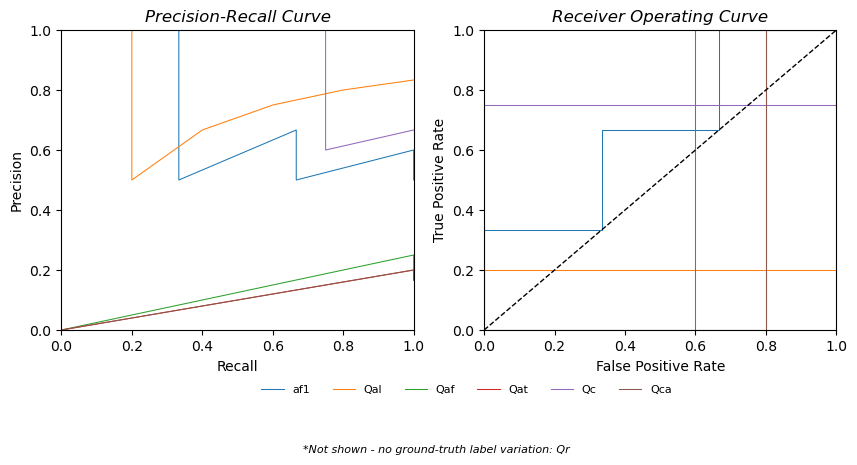

In [8]:
########################################
# Per-Class Performance Visualization
########################################

# precision-recall curve
fig = plot_pr_roc_curves(targets, probabilities, list(SG_MAPPING.keys()))
fig.savefig(f"{output_dir}/id_pr_curves.jpg")

## *Cross-domain Inference*

In [9]:
#############################################
# Inference & Global Performance Metrics
#############################################

# inference...
probabilities, targets = test_model(model, cross_loader, device)

# global performance metrics
df_cross_global = get_global_metrics(targets, probabilities, thresholds=optimal_thresholds)
df_cross_global.to_csv(f"{output_dir}/cd_global.csv", index=False)

df_cross_global.head()

,Precision (Macro),Recall (Macro),F1 (Macro),AUC (Macro),mAP (Macro),Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro)
0,0.416667,0.657143,0.47619,0.394444,0.566905,0.629167,0.8,0.666667,0.471429,0.7525,0.619048


In [10]:
###################################
# Per-Class Performance Metrics
###################################

# class performance metrics
df_cross_class = get_class_metrics(targets, probabilities, thresholds=optimal_thresholds, classes=list(SG_MAPPING.keys()))
df_cross_class.to_csv(f"{output_dir}/cd_class.csv", index=False)

df_cross_class.head(10)

,Class,Threshold,n True,n Predicted,Precision,Recall,Specificity,F1,AUC,AP,Accuracy
0,af1,0.133012,2.0,6.0,0.333333,1.0,0.0,0.500000,0.375000,0.416667,0.333333
1,Qal,0.962361,5.0,4.0,0.750000,0.6,0.0,0.666667,0.600000,0.926667,0.500000
2,Qaf,0.175338,1.0,0.0,0.000000,0.0,1.0,0.000000,0.000000,0.166667,0.833333
3,Qat,0.261770,1.0,0.0,0.000000,0.0,1.0,0.000000,0.600000,0.333333,0.833333
4,Qc,0.500000,3.0,6.0,0.500000,1.0,0.0,0.666667,0.666667,0.833333,0.500000
5,Qca,0.589556,2.0,6.0,0.333333,1.0,0.0,0.500000,0.125000,0.291667,0.333333
6,Qr,0.984239,6.0,6.0,1.000000,1.0,0.0,1.000000,NaN,1.000000,1.000000


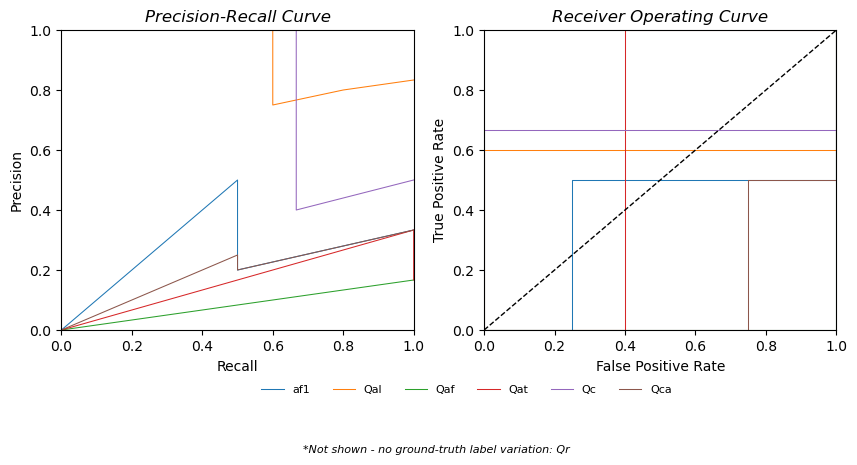

In [11]:
########################################
# Per-Class Performance Visualization
########################################

# precision-recall curve
fig = plot_pr_roc_curves(targets, probabilities, list(SG_MAPPING.keys()))
fig.savefig(f"{output_dir}/cd_pr_curves.jpg")